In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data =pd.read_csv("Customer churn.csv")
df =pd.DataFrame(data)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


replacing black with 0 as tenure is 0 and no total charge are recorded

In [6]:
df["TotalCharges"] =df["TotalCharges"].replace(" ","0")
df["TotalCharges"] =df["TotalCharges"].astype("float")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df["customerID"].duplicated().sum()

np.int64(0)

In [11]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df["SeniorCitizen"] =df["SeniorCitizen"].apply(conv)

***converted 0 and 1 value of senior cotizen to yes/no to make it easier to understand***

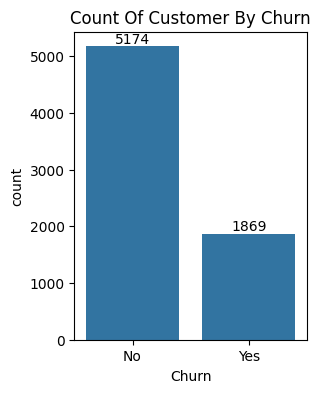

In [12]:
plt.figure(figsize=(3,4))
ax = sns.countplot(x ="Churn",data =df)
plt.title("Count Of Customer By Churn")
ax.bar_label(ax.containers[0])
plt.show()

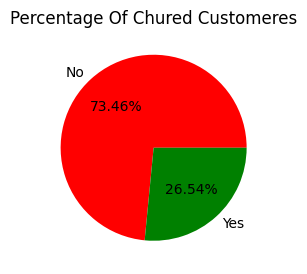

In [13]:
plt.figure(figsize=(3,4))
gb =df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb["Churn"],labels=gb.index,autopct="%1.2f%%",colors=["red","green"])
plt.title("Percentage Of Chured Customeres")
plt.show()

#From the given pie chart we can conclude that 26.54% of our customers have churned out .
#Not let's explore the reason behind it 

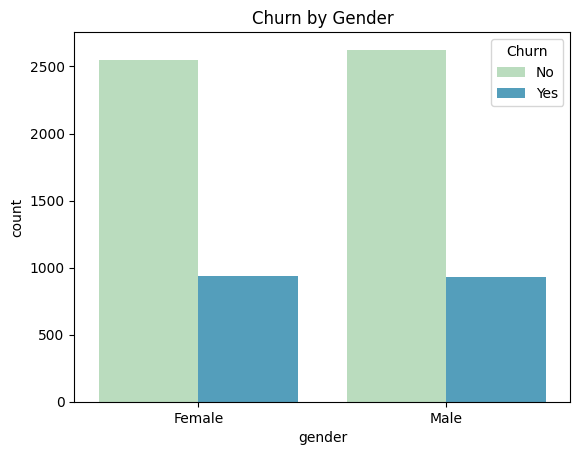

In [18]:
plt.Figure( figsize= (3,3)) 
sns.countplot(x ="gender",data=df,hue="Churn",palette="GnBu") 
plt.title("Churn by Gender") 
plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_100832\4032056603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.countplot(x ="SeniorCitizen",data=df,palette="GnBu")


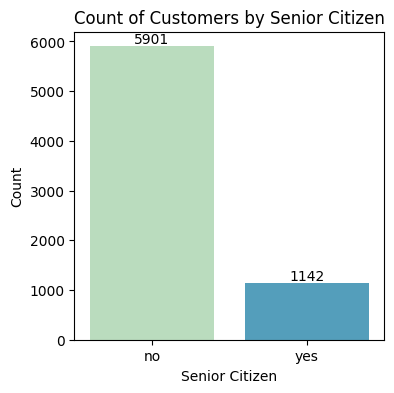

In [ ]:
plt.figure( figsize= (4,4)) 
ax =sns.countplot(x ="SeniorCitizen",data=df,palette="GnBu")
for bar in ax.patches:
    count = int(bar.get_height())
    ax.annotate(
        count,
        (bar.get_x() + bar.get_width()/2, count),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Count of Customers by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")
plt.show()


#comparative a greated pecentage of people in senior citizen categary have chured

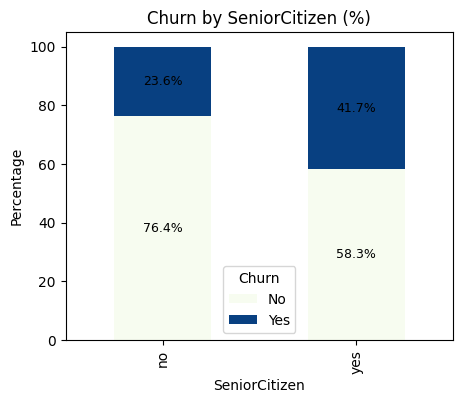

In [17]:
# count data
count_df = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# convert to percentage (row-wise)
percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100

ax = percent_df.plot(
    kind='bar',
    stacked=True,
    figsize=(5,4),
    colormap='GnBu'
)

plt.title("Churn by SeniorCitizen (%)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v:.1f}%' if v > 0 else '' for v in container.datavalues],
        label_type='center',
        fontsize=9
    )

plt.show()



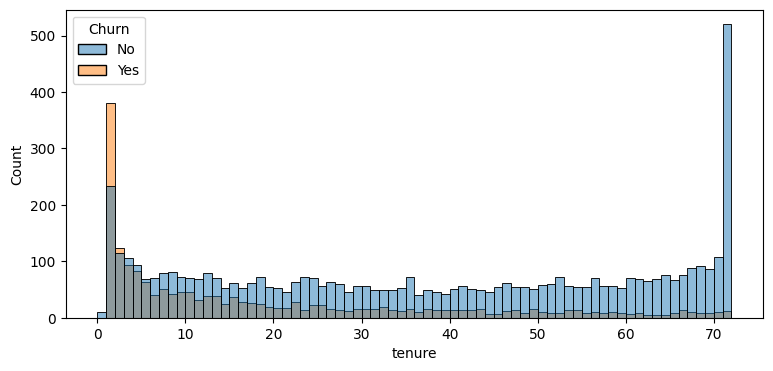

In [39]:
plt.figure( figsize= (9,4)) 
sns.histplot(x ="tenure",data=df,bins=72,hue="Churn")
plt.show()

#people who have usend our services for a long time have stayed and people who have used our services #1 or #2 months have churned

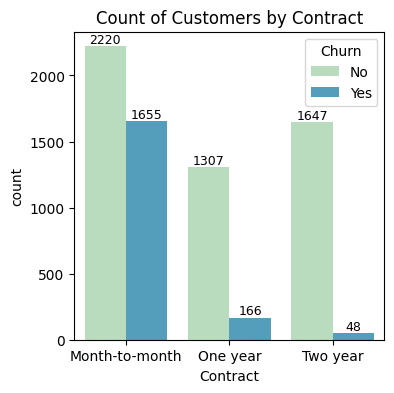

In [48]:
plt.figure( figsize= (4,4)) 
ax =sns.countplot(x ="Contract",hue="Churn",data=df,palette="GnBu")
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
plt.title("Count of Customers by Contract")
plt.show()


#people who have month to month contract are likely to churn then from who have 1 or 2 years or contract

In [50]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

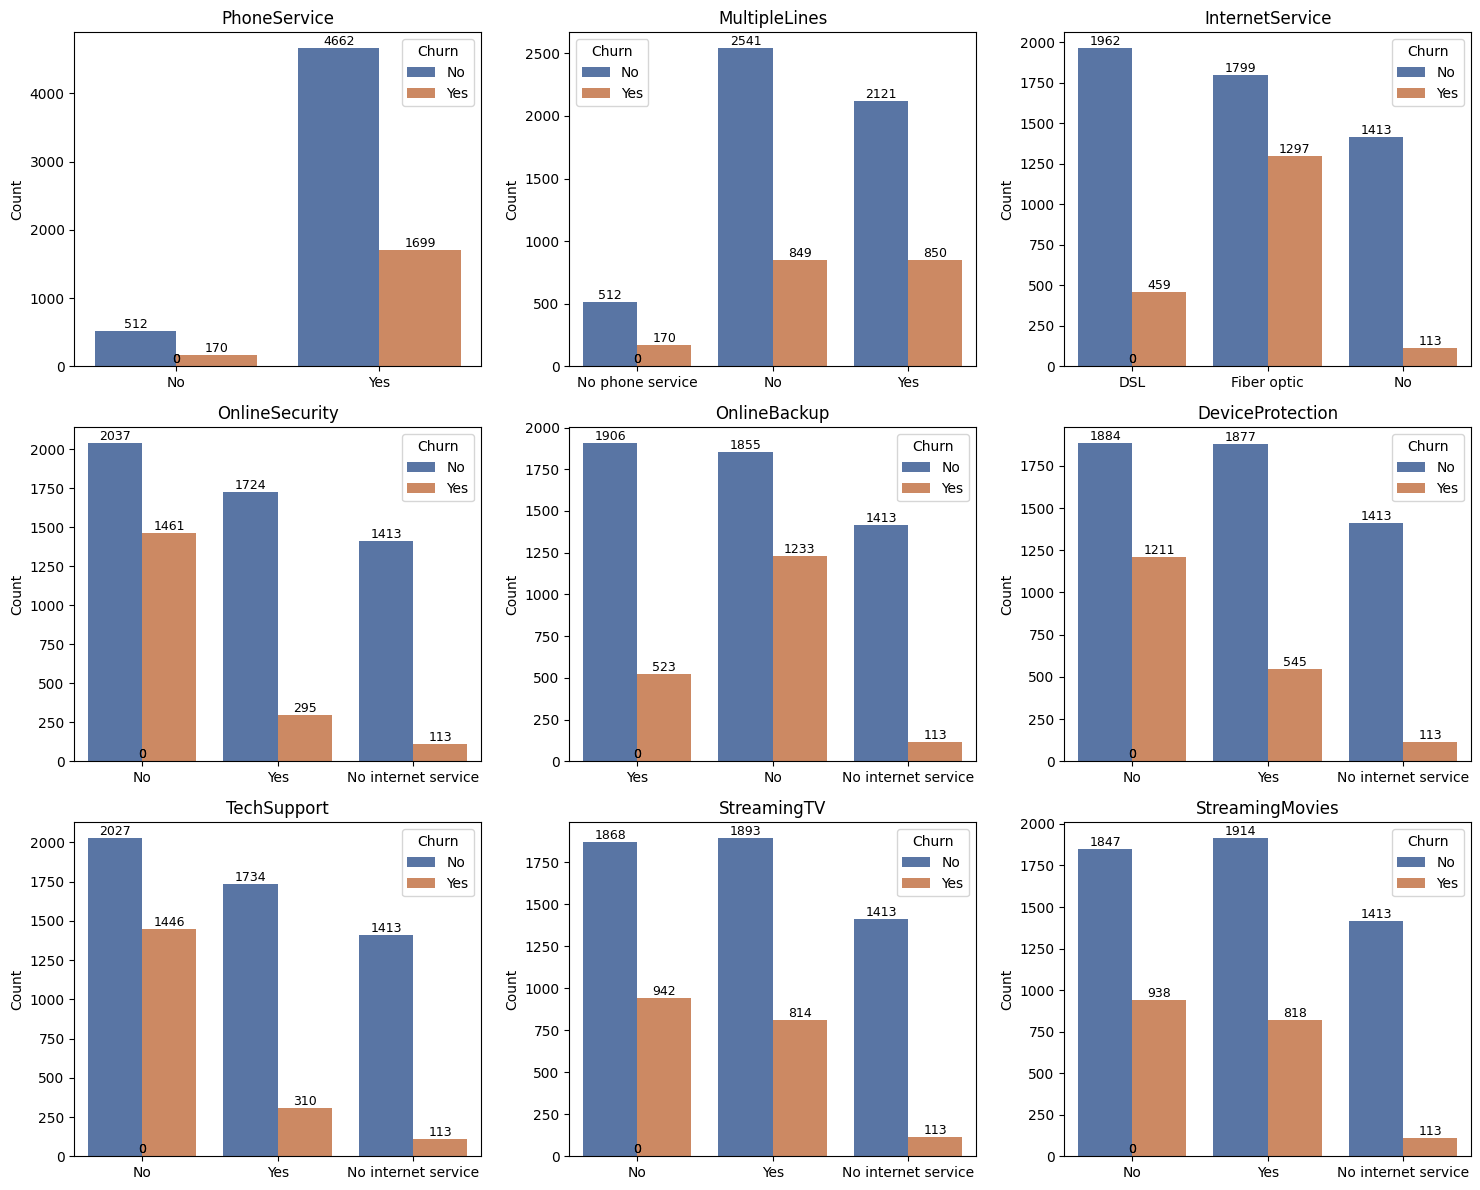

In [62]:

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# subplot layout
rows = 3
cols_n = 3

fig, axes = plt.subplots(rows, cols_n, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    sns.countplot(
        x=col,
        data=df,
        palette="deep",
        ax=ax,
        hue=df["Churn"]
    )

    # add count labels
    for bar in ax.patches:
        ax.annotate(
            int(bar.get_height()),
            (bar.get_x() + bar.get_width()/2, bar.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# remove empty subplots if any
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#Most customers have PhoneService and InternetService, with fiber optic users showing the highest churn counts among internet types. Customers without OnlineSecurity, TechSupport, and DeviceProtection consistently show much higher churn compared to those who have these services. Add-on services like OnlineBackup, StreamingTV, and StreamingMovies are common, but churn remains higher among users not subscribed to core support/security services. Overall, service protection and support features are strongly associated with lower churn.

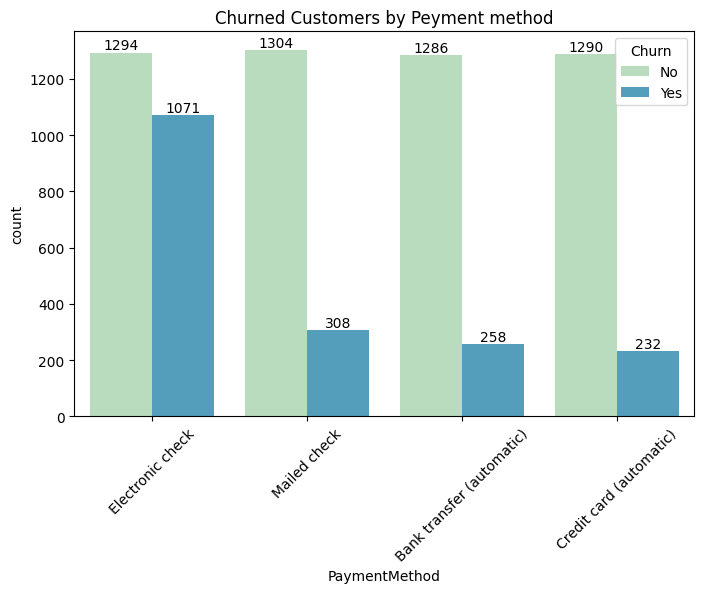

In [69]:
plt.figure( figsize= (8,5)) 
ax =sns.countplot(x ="PaymentMethod",hue="Churn",data=df,palette="GnBu")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Peyment method")
plt.xticks(rotation=45)
plt.show()


#customer is likely to churend when he is using electronic check as a payment method